In [49]:
! pip install -r requirements.txt

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [51]:
data = pd.read_csv("data.csv")
data.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


<Axes: >

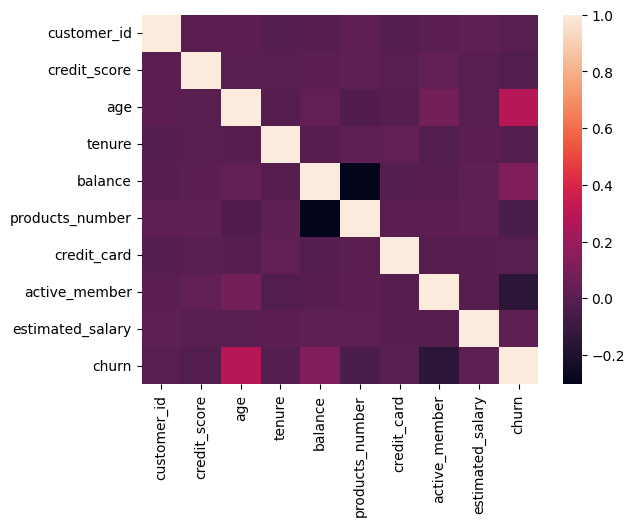

In [52]:
corr = data.corr(numeric_only=True)
sns.heatmap(corr)

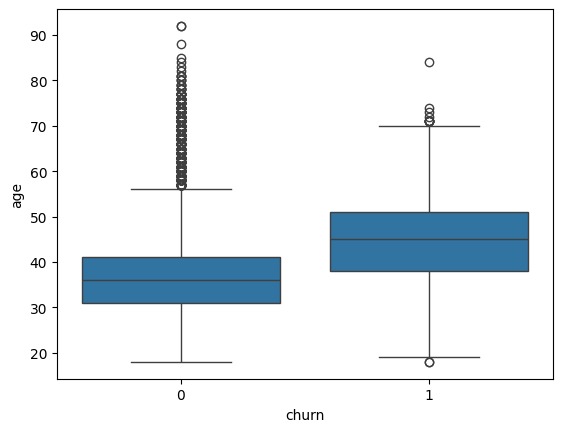

In [53]:
sns.boxplot(x="churn", y="age", data=data)
plt.show()

In [54]:
from sklearn.preprocessing import LabelEncoder
enc = LabelEncoder()
data['encoded'] = enc.fit_transform(data['gender'])
data[['churn','encoded']].head()

,churn,encoded
0,1,0
1,0,0
2,1,0
3,0,0
4,0,0


In [55]:
data['encoded'].value_counts()

encoded
1    5457
0    4543
Name: count, dtype: int64

In [56]:
data.columns

Index(['customer_id', 'credit_score', 'country', 'gender', 'age', 'tenure',
       'balance', 'products_number', 'credit_card', 'active_member',
       'estimated_salary', 'churn', 'encoded'],
      dtype='str')

In [57]:
y=data['churn']
X = data[[ 'credit_score', 'age', 'tenure',
       'balance', 'products_number', 'credit_card', 'active_member',
       'estimated_salary', 'encoded']]

In [58]:
from sklearn.model_selection import train_test_split
X_tr,X_test, y_tr, y_test = train_test_split(X,y, test_size=0.2)

In [59]:
from sklearn.preprocessing import StandardScaler
scaling = StandardScaler()
scaling.fit(X_tr)

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [60]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=100000)
model.fit(X_tr, y_tr)
model.score(X_test, y_test)

0.812

In [61]:
from sklearn.pipeline import make_pipeline
test_score = []

for lam in np.arange(0.01, 100, 0.1):
    pipe = make_pipeline(StandardScaler(), LogisticRegression(max_iter = 100 ,C=1/lam))
    pipe.fit(X_tr, y_tr)
    score = pipe.score(X_test, y_test)
    test_score.append(score)

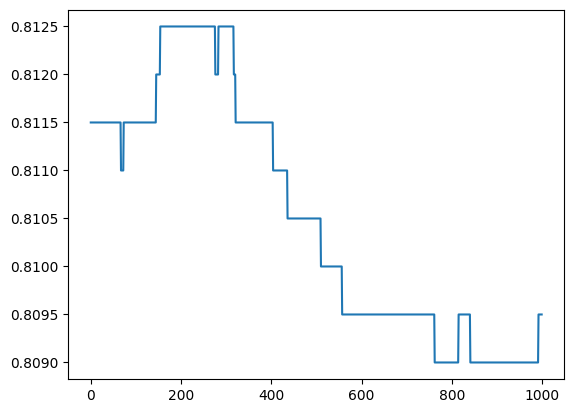

In [65]:
plt.plot(test_score)